# Estimasi Distribusi Fase Siklus Sel dari Data Flow Cytometry Menggunakan Model Dean-Jett-Fox

## Abstrak

Analisis kandungan DNA dengan flow cytometry dapat digunakan untuk memperkirakan distribusi sel pada fase G1, S, dan G2/M. Penelitian ini menggunakan data FCS publik Zenodo 14928071 yang memuat pengukuran propidium iodide (PI) pada dua kondisi eksperimen, yaitu AI dan AX, masing-masing pada 0, 24, 48, dan 72 jam. Intensitas PI-A dipakai sebagai pendekatan terhadap kandungan DNA per sel, kemudian diringkas menjadi histogram dan dianalisis dengan model Dean-Jett-Fox.

Model yang digunakan memisahkan histogram DNA menjadi puncak G1, distribusi S, dan puncak G2/M. G1 dan G2/M direpresentasikan sebagai Gaussian, sedangkan S direpresentasikan sebagai polynomial S phase orde dua di antara G1 dan G2/M. Distribusi S kemudian mengalami broadening untuk meniru pelebaran sinyal akibat variasi preparasi dan instrumen. Model juga menyertakan komponen debris dan background agar sinyal rendah di luar populasi utama tidak langsung dihitung sebagai fase siklus sel.

Hasil yang diperoleh harus dibaca sebagai estimasi berbasis model. Tidak ada label fase sel individual pada dataset ini, sehingga residual, weighted residual, R-squared, reduced chi-square, dan warning model digunakan sebagai batas interpretasi biologis.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

SCRIPTS_DIR = ROOT / "scripts"
PROCESSED_SUMMARY = ROOT / "data" / "processed" / "zenodo_14928071_histograms_summary.json"
FIT_SUMMARY_CSV = ROOT / "data" / "processed" / "zenodo_14928071_djf_fit_summary.csv"

for import_path in [ROOT, SCRIPTS_DIR]:
    import_path_text = str(import_path)
    if import_path_text not in sys.path:
        sys.path.insert(0, import_path_text)

from models.dean_jett_fox import fit_dean_jett_fox

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 40)


## Pendahuluan

Siklus sel menggambarkan urutan proses yang dilalui sel ketika tumbuh, menggandakan materi genetik, dan membelah. Dalam analisis kandungan DNA, fase G1 berkaitan dengan populasi sel berkandungan DNA 2N, fase S berkaitan dengan proses sintesis DNA ketika kandungan DNA bergerak dari 2N menuju 4N, dan fase G2/M berkaitan dengan populasi sel berkandungan DNA 4N. Perubahan proporsi ketiga fase ini memberi gambaran tentang status proliferasi dan respons populasi sel terhadap kondisi biologis tertentu.

Flow cytometry memungkinkan pengukuran intensitas fluoresensi ribuan sel secara cepat. Pada pewarnaan propidium iodide, intensitas fluoresensi berkaitan dengan jumlah DNA, sehingga distribusi intensitas dapat dipakai untuk membangun histogram DNA content. Histogram seperti ini tidak langsung memberikan batas fase yang tegas karena sinyal dapat melebar akibat variasi pewarnaan, noise instrumen, debris, doublet, dan heterogenitas sampel. Karena itu, diperlukan model komputasi yang memisahkan kontribusi G1, S, dan G2/M secara eksplisit.

Model Dean-Jett-Fox dipilih karena secara historis dikembangkan untuk analisis distribusi DNA hasil flow microfluorometry dan tetap digunakan dalam perangkat analisis cell cycle modern. Kekuatan model ini bukan hanya pada pemisahan dua puncak Gaussian, tetapi juga pada representasi fase S sebagai distribusi kontinu di antara puncak 2N dan 4N.


## Pertanyaan Penelitian

Analisis ini menjawab pertanyaan utama berikut: bagaimana model Dean-Jett-Fox dapat digunakan untuk mengestimasi proporsi fase G1, S, dan G2/M dari histogram PI-A flow cytometry?

Pertanyaan tersebut dijabarkan menjadi tiga pertanyaan pendukung. Pertama, seberapa baik kurva model mengikuti histogram berdasarkan residual, weighted residual, RMSE, R-squared, dan reduced chi-square? Kedua, bagaimana pola estimasi fase pada kondisi AI dan AX berubah dari 0 sampai 72 jam? Ketiga, keterbatasan apa yang harus diperhatikan ketika hasil fitting ditafsirkan sebagai informasi biologis?


## Dasar Biologi Siklus Sel dan Pengukuran PI-A

Pada populasi sel yang dianalisis berdasarkan kandungan DNA, G1 biasanya tampak sebagai puncak utama pertama karena sel masih memiliki kandungan DNA 2N. Fase S tidak membentuk satu puncak tunggal; sel pada fase ini sedang menggandakan DNA sehingga intensitasnya tersebar di antara 2N dan 4N. Fase G2/M biasanya muncul sebagai puncak kedua karena sel telah mencapai kandungan DNA 4N sebelum atau saat pembelahan.

Propidium iodide berikatan dengan DNA setelah preparasi sel yang sesuai. Karena jumlah pewarna yang terikat berkaitan dengan jumlah DNA, channel PI-A digunakan sebagai proksi kandungan DNA. Channel PI-A dipilih karena parameter tersebut merepresentasikan area sinyal PI, sedangkan PI-H dan PI-W lebih sering dipakai sebagai informasi pendukung untuk tinggi dan lebar pulsa. Pemilihan PI-A tetap memiliki keterbatasan: tanpa gating rinci, histogram dapat memuat debris, doublet, dan event teknis yang bukan populasi fase siklus sel yang ideal.


## Data dan Preprocessing

Dataset Zenodo 14928071 menyediakan file FCS dari dua kondisi eksperimen, AI dan AX, pada empat timepoint: 0, 24, 48, dan 72 jam. Setiap file FCS dibaca untuk mengambil channel PI-A, kemudian nilai non-finite dan nilai negatif dikeluarkan sebelum histogram dibuat. Histogram menggunakan 256 bin dengan rentang percentile 0.5 sampai 99.5 agar outlier ekstrem tidak mendominasi skala visual.

Preprocessing ini menghasilkan representasi satu dimensi dari distribusi kandungan DNA. Pendekatan tersebut memadai untuk pemodelan Dean-Jett-Fox, tetapi belum menggantikan gating biologis lengkap. Oleh karena itu, hasil fitting selalu ditafsirkan bersama kualitas fit dan warning model.


In [2]:
from preprocess_zenodo_histograms import main as preprocess_main

if not PROCESSED_SUMMARY.exists():
    exit_code = preprocess_main()
    if exit_code != 0:
        raise RuntimeError("Preprocessing histogram gagal")

items = json.loads(PROCESSED_SUMMARY.read_text(encoding="utf-8"))
items = sorted(items, key=lambda row: (row["condition"], int(row["timepoint_hours"])))
summary_df = pd.DataFrame(
    {
        "condition": item["condition"],
        "timepoint_hours": int(item["timepoint_hours"]),
        "source_file": item["source_file"],
        "channel": item["channel"],
        "events_total": item["events_total"],
        "events_used": item["events_used"],
        "bin_count": item["bin_count"],
        "histogram_min": item["histogram_range"][0],
        "histogram_max": item["histogram_range"][1],
    }
    for item in items
)
summary_df


,condition,timepoint_hours,source_file,channel,events_total,events_used,bin_count,histogram_min,histogram_max
0,AI,0,Specimen_001_AI_0_001.fcs,PI-A,54449,54206,256,41.385563,140809.312500
1,AI,24,Specimen_001_AI_24_002.fcs,PI-A,54432,54279,256,57.411930,149489.000000
2,AI,48,Specimen_001_AI_48_003.fcs,PI-A,59684,59509,256,50.705849,230842.671875
3,AI,72,Specimen_001_AI_72_004.fcs,PI-A,68301,67939,256,24.942532,172122.781250
4,AX,0,Specimen_001_AX_0_005.fcs,PI-A,54472,54214,256,30.574799,142810.125000
5,AX,24,Specimen_001_AX_24_006.fcs,PI-A,54305,54151,256,51.270885,141937.421875
6,AX,48,Specimen_001_AX_48_007.fcs,PI-A,53997,53801,256,51.386150,151043.296875
7,AX,72,Specimen_001_AX_72_008.fcs,PI-A,54606,54454,256,55.382885,169777.687500


## Model Dean-Jett-Fox

Model Dean-Jett-Fox membangun fungsi prediksi histogram dari beberapa komponen biologis dan teknis. Puncak G1 diposisikan pada kandungan DNA relatif 2N, sedangkan puncak G2/M diposisikan pada kandungan DNA yang lebih tinggi dan secara biologis diharapkan mendekati rasio 4N terhadap 2N. Kedua puncak ini dimodelkan sebagai Gaussian berbasis area sehingga luas kurva dapat dihubungkan dengan estimasi jumlah sel pada fase tersebut.

Fase S direpresentasikan dengan polynomial S phase orde dua yang hanya aktif di antara mean G1 dan mean G2/M. Representasi polynomial memberi fleksibilitas karena distribusi sel pada fase S tidak harus simetris. Setelah polynomial dibentuk, komponen S mengalami broadening menggunakan Gaussian kernel yang dikaitkan dengan coefficient of variation G1. Broadening ini mencerminkan gagasan bahwa histogram observed lebih lebar daripada distribusi biologis ideal akibat variasi preparasi dan instrumen.

Selain tiga komponen fase, model menyertakan debris rendah-DNA dan background konstan. Debris membantu menampung sinyal pada sisi kiri histogram yang tidak seharusnya langsung dihitung sebagai G1. Background menampung sinyal datar residual. Kedua komponen tersebut tidak dimasukkan ke normalisasi persentase G1, S, dan G2/M.

Parameter dicari dengan least-squares berbobot. Weighted residual dihitung dengan membagi residual terhadap akar hitungan observed sehingga bin dengan hitungan sangat besar tidak sepenuhnya mendominasi optimisasi. Evaluasi fit mencakup SSE, RMSE, R-squared, weighted SSE, reduced chi-square, dan warning parameter biologis.


In [3]:
fit_results = []
for item in items:
    fit = fit_dean_jett_fox(item["bins"], item["counts"])
    fit_results.append({"item": item, "fit": fit})

rows = []
for entry in fit_results:
    item = entry["item"]
    fit = entry["fit"]
    metrics = fit["fit_metrics"]
    phases = fit["phase_percentages"]
    params = fit["parameters"]
    rows.append(
        {
            "condition": item["condition"],
            "timepoint_hours": int(item["timepoint_hours"]),
            "source_file": item["source_file"],
            "channel": item["channel"],
            "g1_percent": phases["g1"],
            "s_percent": phases["s"],
            "g2_m_percent": phases["g2_m"],
            "rmse": metrics["rmse"],
            "r_squared": metrics["r_squared"],
            "weighted_sse": metrics["weighted_sse"],
            "reduced_chi_square": metrics["reduced_chi_square"],
            "g2_g1_ratio": params["g2_g1_ratio"],
            "debris_percent_of_total_signal": params["debris_percent_of_total_signal"],
            "model_version": fit["model_info"]["version"],
            "warnings": "; ".join(fit["warnings"]),
        }
    )

fit_df = pd.DataFrame(rows).sort_values(["condition", "timepoint_hours"])
FIT_SUMMARY_CSV.parent.mkdir(parents=True, exist_ok=True)
fit_df.to_csv(FIT_SUMMARY_CSV, index=False)
fit_df


,condition,timepoint_hours,source_file,channel,g1_percent,s_percent,g2_m_percent,rmse,r_squared,weighted_sse,reduced_chi_square,g2_g1_ratio,debris_percent_of_total_signal,model_version,warnings
0,AI,0,Specimen_001_AI_0_001.fcs,PI-A,60.912854,3.403637e+01,5.050780,116.253236,0.867012,3940.508497,16.216084,2.003223,2.265728,djf_polynomial_broadened_v2,
1,AI,24,Specimen_001_AI_24_002.fcs,PI-A,84.959145,1.176374e+01,3.277112,118.213056,0.933643,3609.385886,14.853440,1.998302,2.169589,djf_polynomial_broadened_v2,Polynomial S phase berada dekat batas non-nega...
2,AI,48,Specimen_001_AI_48_003.fcs,PI-A,89.624945,7.297831e+00,3.077224,181.133561,0.893609,6713.715308,27.628458,2.000595,14.252921,djf_polynomial_broadened_v2,Reduced chi-square tinggi; residual berbobot m...
3,AI,72,Specimen_001_AI_72_004.fcs,PI-A,92.975021,1.418041e-12,7.024979,256.351716,0.687036,10809.671075,44.484243,2.104209,10.881291,djf_polynomial_broadened_v2,R-squared rendah; interpretasi fase perlu hati...
4,AX,0,Specimen_001_AX_0_005.fcs,PI-A,59.146996,3.584581e+01,5.007191,102.404386,0.895297,3375.959836,13.892839,2.001756,2.319207,djf_polynomial_broadened_v2,
5,AX,24,Specimen_001_AX_24_006.fcs,PI-A,63.695909,3.111871e+01,5.185379,127.389639,0.853592,4744.834750,19.526069,2.006732,2.160305,djf_polynomial_broadened_v2,Polynomial S phase berada dekat batas non-nega...
6,AX,48,Specimen_001_AX_48_007.fcs,PI-A,58.425561,3.641338e+01,5.161063,86.488479,0.923660,2743.679271,11.290861,2.006926,1.980872,djf_polynomial_broadened_v2,Polynomial S phase berada dekat batas non-nega...
7,AX,72,Specimen_001_AX_72_008.fcs,PI-A,58.440432,3.715462e+01,4.404945,103.783712,0.905473,3364.205870,13.844469,2.027061,2.254280,djf_polynomial_broadened_v2,Polynomial S phase berada dekat batas non-nega...


## Hasil: Histogram PI-A

Histogram PI-A memperlihatkan bentuk distribusi DNA yang menjadi dasar estimasi fase. Puncak dengan intensitas lebih rendah berhubungan dengan populasi 2N, area di antaranya berhubungan dengan fase S, dan puncak atau bahu pada intensitas lebih tinggi berhubungan dengan populasi 4N. Bentuk tersebut tidak selalu ideal; beberapa sampel memperlihatkan noise dan ekor distribusi yang memengaruhi stabilitas fitting.


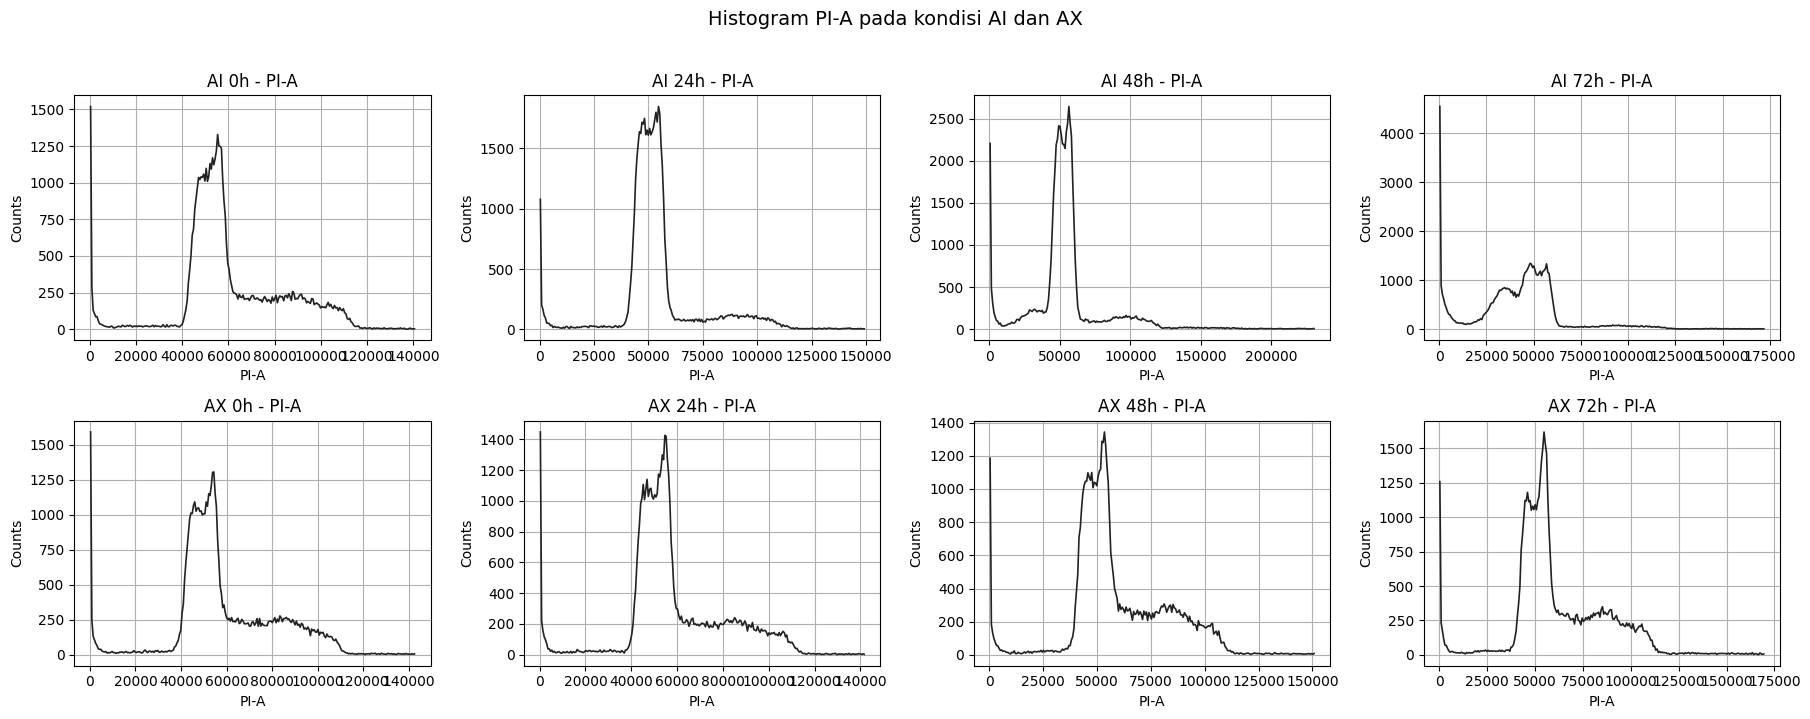

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=False)
for ax, item in zip(axes.ravel(), items):
    ax.plot(item["bins"], item["counts"], color="#222222", linewidth=1.2)
    ax.set_title(f"{item['condition']} {item['timepoint_hours']}h - {item['channel']}")
    ax.set_xlabel("PI-A")
    ax.set_ylabel("Counts")
fig.suptitle("Histogram PI-A pada kondisi AI dan AX", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


## Hasil: Kurva Model dan Komponen Fase

Kurva fit total dibandingkan dengan histogram observed untuk menilai apakah model cukup menangkap bentuk distribusi. Komponen G1, S, dan G2/M ditampilkan bersama debris dan background agar kontribusi teknis tidak tertukar dengan fase biologis. Garis S unbroadened menunjukkan bentuk polynomial sebelum pelebaran, sedangkan komponen S utama menunjukkan distribusi setelah broadening.


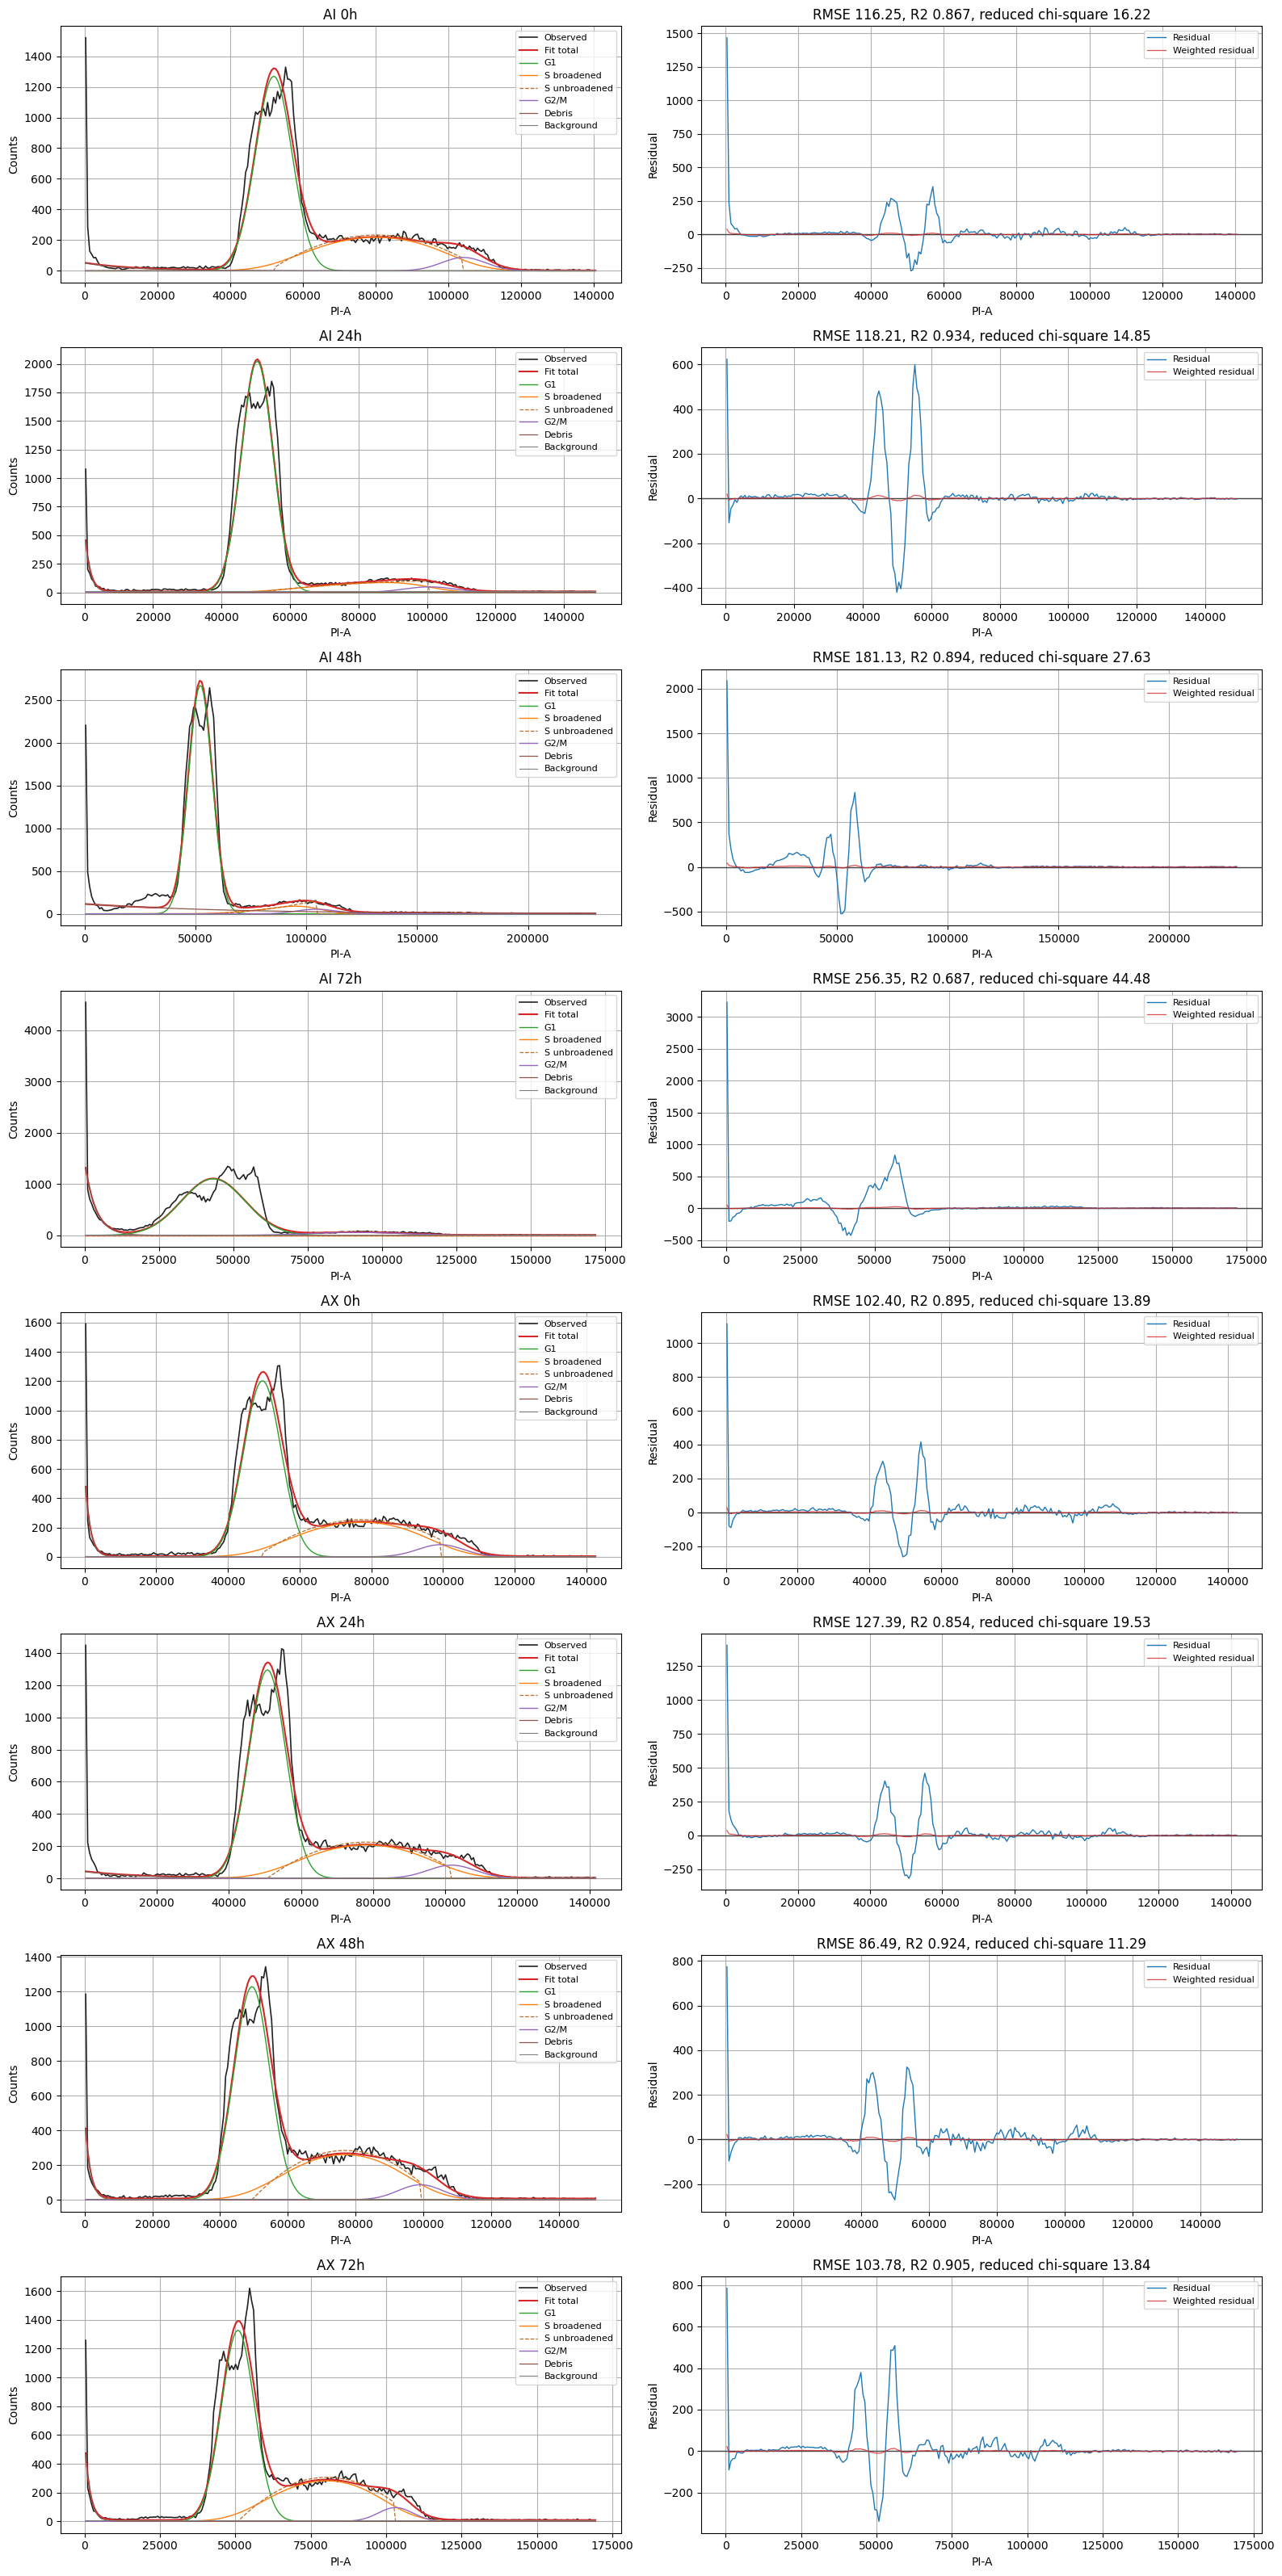

In [5]:
fig, axes = plt.subplots(len(fit_results), 2, figsize=(16, 4 * len(fit_results)))
for row_idx, entry in enumerate(fit_results):
    item = entry["item"]
    fit = entry["fit"]
    series = fit["series"]
    metrics = fit["fit_metrics"]
    ax_fit = axes[row_idx, 0]
    ax_res = axes[row_idx, 1]

    ax_fit.plot(series["bins"], series["observed"], label="Observed", color="#222222", linewidth=1.2)
    ax_fit.plot(series["bins"], series["fit_total"], label="Fit total", color="#d62728", linewidth=1.5)
    ax_fit.plot(series["bins"], series["g1"], label="G1", color="#2ca02c", linewidth=1.0)
    ax_fit.plot(series["bins"], series["s"], label="S broadened", color="#ff7f0e", linewidth=1.0)
    ax_fit.plot(series["bins"], series["s_unbroadened"], label="S unbroadened", color="#bc6c25", linestyle="--", linewidth=0.9)
    ax_fit.plot(series["bins"], series["g2_m"], label="G2/M", color="#9467bd", linewidth=1.0)
    ax_fit.plot(series["bins"], series["debris"], label="Debris", color="#8c564b", linewidth=0.9)
    ax_fit.plot(series["bins"], series["background"], label="Background", color="#7f7f7f", linewidth=0.8)
    ax_fit.set_title(f"{item['condition']} {item['timepoint_hours']}h")
    ax_fit.set_xlabel("PI-A")
    ax_fit.set_ylabel("Counts")
    ax_fit.legend(loc="upper right", fontsize=8)

    ax_res.axhline(0, color="#444444", linewidth=1.0)
    ax_res.plot(series["bins"], series["residual"], color="#1f77b4", linewidth=1.0, label="Residual")
    ax_res.plot(series["bins"], series["weighted_residual"], color="#d62728", linewidth=0.9, alpha=0.8, label="Weighted residual")
    r2 = metrics["r_squared"]
    r2_text = "NA" if r2 is None else f"{r2:.3f}"
    ax_res.set_title(f"RMSE {metrics['rmse']:.2f}, R2 {r2_text}, reduced chi-square {metrics['reduced_chi_square']:.2f}")
    ax_res.set_xlabel("PI-A")
    ax_res.set_ylabel("Residual")
    ax_res.legend(loc="upper right", fontsize=8)

fig.tight_layout()
plt.show()


## Hasil: Estimasi Fase dan Kualitas Fit

Tabel berikut merangkum estimasi persentase G1, S, dan G2/M bersama metrik kualitas fit. Persentase fase dinormalisasi hanya dari komponen G1, S, dan G2/M; debris dan background dikeluarkan dari normalisasi tersebut. Rasio G2/G1 digunakan sebagai pemeriksaan biologis karena populasi 4N idealnya berada sekitar dua kali posisi 2N, walaupun deviasi dapat terjadi akibat kualitas data, gating, dan karakteristik preparasi.


In [6]:
def classify_fit(row: pd.Series) -> str:
    r2 = row["r_squared"]
    reduced = row["reduced_chi_square"]
    if pd.isna(r2) or r2 < 0.80 or reduced > 25:
        return "lemah"
    if r2 >= 0.90 and reduced <= 10:
        return "kuat"
    return "cukup"

analysis_df = fit_df.copy()
analysis_df["fit_quality"] = analysis_df.apply(classify_fit, axis=1)
analysis_df["dominant_phase"] = analysis_df[["g1_percent", "s_percent", "g2_m_percent"]].idxmax(axis=1).map(
    {"g1_percent": "G1", "s_percent": "S", "g2_m_percent": "G2/M"}
)
analysis_df[
    [
        "condition",
        "timepoint_hours",
        "g1_percent",
        "s_percent",
        "g2_m_percent",
        "r_squared",
        "reduced_chi_square",
        "g2_g1_ratio",
        "debris_percent_of_total_signal",
        "fit_quality",
        "dominant_phase",
        "warnings",
    ]
]


,condition,timepoint_hours,g1_percent,s_percent,g2_m_percent,r_squared,reduced_chi_square,g2_g1_ratio,debris_percent_of_total_signal,fit_quality,dominant_phase,warnings
0,AI,0,60.912854,3.403637e+01,5.050780,0.867012,16.216084,2.003223,2.265728,cukup,G1,
1,AI,24,84.959145,1.176374e+01,3.277112,0.933643,14.853440,1.998302,2.169589,cukup,G1,Polynomial S phase berada dekat batas non-nega...
2,AI,48,89.624945,7.297831e+00,3.077224,0.893609,27.628458,2.000595,14.252921,lemah,G1,Reduced chi-square tinggi; residual berbobot m...
3,AI,72,92.975021,1.418041e-12,7.024979,0.687036,44.484243,2.104209,10.881291,lemah,G1,R-squared rendah; interpretasi fase perlu hati...
4,AX,0,59.146996,3.584581e+01,5.007191,0.895297,13.892839,2.001756,2.319207,cukup,G1,
5,AX,24,63.695909,3.111871e+01,5.185379,0.853592,19.526069,2.006732,2.160305,cukup,G1,Polynomial S phase berada dekat batas non-nega...
6,AX,48,58.425561,3.641338e+01,5.161063,0.923660,11.290861,2.006926,1.980872,cukup,G1,Polynomial S phase berada dekat batas non-nega...
7,AX,72,58.440432,3.715462e+01,4.404945,0.905473,13.844469,2.027061,2.254280,cukup,G1,Polynomial S phase berada dekat batas non-nega...


Secara umum, estimasi fase menunjukkan bahwa komponen G1 tetap menjadi bagian penting pada sebagian besar sampel, tetapi model polynomial S phase memberi ruang yang lebih fleksibel bagi distribusi S dibanding bentuk S yang simetris tetap. Sampel dengan R-squared tinggi dan reduced chi-square lebih rendah memiliki dasar interpretasi yang lebih kuat. Sebaliknya, sampel dengan warning residual atau rasio G2/G1 yang jauh dari ekspektasi harus dibaca sebagai fit yang terbatas.

Sampel AI 72h perlu diperhatikan secara khusus bila metrik fit tetap buruk. Kondisi tersebut tidak boleh ditafsirkan sebagai bukti biologis kuat bahwa populasi benar-benar berada pada satu fase tertentu. Interpretasi yang lebih hati-hati adalah bahwa bentuk histogram pada sampel tersebut sulit direpresentasikan oleh asumsi model sederhana, sehingga estimasi fase memiliki ketidakpastian lebih tinggi.


## Perbandingan Kondisi AI dan AX

Perbandingan timepoint memberi gambaran deskriptif tentang perubahan distribusi fase menurut model. Karena dataset tidak menyediakan label fase individual, perbedaan antara AI dan AX tidak ditafsirkan sebagai mekanisme kausal. Perbandingan ini lebih tepat dibaca sebagai pola estimasi dari histogram PI-A yang telah difit dengan model yang sama.


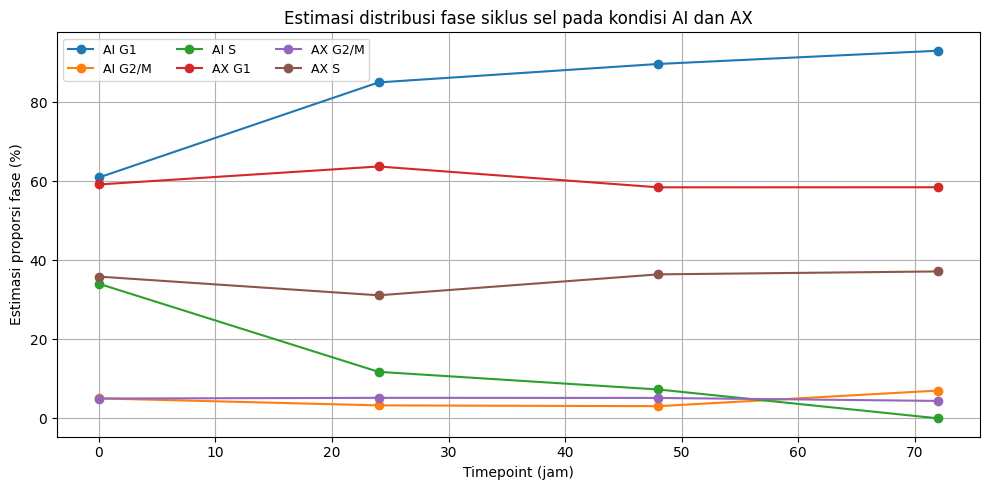

g1_percent                s_percent            g2_m_percent  \
condition               AI         AX            AI         AX           AI   
timepoint_hours                                                               
0                60.912854  59.146996  3.403637e+01  35.845813     5.050780   
24               84.959145  63.695909  1.176374e+01  31.118711     3.277112   
48               89.624945  58.425561  7.297831e+00  36.413377     3.077224   
72               92.975021  58.440432  1.418041e-12  37.154623     7.024979   

                          r_squared           reduced_chi_square             
condition              AX        AI        AX                 AI         AX  
timepoint_hours                                                              
0                5.007191  0.867012  0.895297          16.216084  13.892839  
24               5.185379  0.933643  0.853592          14.853440  19.526069  
48               5.161063  0.893609  0.923660          27.628458  11.290861  
72               4.404945  0.687036  0.905473          44.484243  13.844469

In [7]:
phase_long = fit_df.melt(
    id_vars=["condition", "timepoint_hours"],
    value_vars=["g1_percent", "s_percent", "g2_m_percent"],
    var_name="phase",
    value_name="percent",
)
phase_long["phase"] = phase_long["phase"].map(
    {"g1_percent": "G1", "s_percent": "S", "g2_m_percent": "G2/M"}
)

fig, ax = plt.subplots(figsize=(10, 5))
for (condition, phase), group in phase_long.groupby(["condition", "phase"]):
    group = group.sort_values("timepoint_hours")
    ax.plot(group["timepoint_hours"], group["percent"], marker="o", label=f"{condition} {phase}")
ax.set_xlabel("Timepoint (jam)")
ax.set_ylabel("Estimasi proporsi fase (%)")
ax.set_title("Estimasi distribusi fase siklus sel pada kondisi AI dan AX")
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
plt.show()

fit_df.pivot(index="timepoint_hours", columns="condition", values=["g1_percent", "s_percent", "g2_m_percent", "r_squared", "reduced_chi_square"])


Pada timepoint awal, kedua kondisi memperlihatkan kontribusi beberapa komponen fase, sehingga histogram tidak hanya dijelaskan oleh satu puncak G1. Seiring waktu, pola AI dan AX dapat berbeda dalam besar kontribusi G1, S, dan G2/M. Pola tersebut memberi indikasi bahwa kondisi eksperimen memengaruhi distribusi DNA content, tetapi kekuatan kesimpulan tetap bergantung pada kualitas fit masing-masing sampel.

Apabila kondisi AX memperlihatkan kontribusi S dan G2/M yang lebih stabil dibanding AI, hal tersebut dapat dideskripsikan sebagai perbedaan distribusi fase menurut model. Namun, interpretasi biologis tetap dibatasi oleh tidak adanya ground truth fase, belum lengkapnya gating, dan kemungkinan kontribusi debris atau doublet pada histogram.


## Pembahasan

Model Dean-Jett-Fox yang digunakan dalam analisis ini menghubungkan konsep biologis siklus sel dengan bentuk matematis histogram DNA. Puncak G1 merepresentasikan populasi 2N, puncak G2/M merepresentasikan populasi 4N, dan polynomial S phase merepresentasikan sel yang sedang mengalami sintesis DNA di antara dua keadaan tersebut. Broadening pada komponen S penting karena distribusi observed bukan hanya hasil variasi biologis, melainkan juga dipengaruhi oleh noise instrumen dan preparasi sampel.

Penambahan debris dan background membuat model lebih hati-hati dalam membaca sinyal rendah. Tanpa komponen tersebut, sinyal di sisi kiri histogram dapat meningkatkan estimasi G1 secara artifisial. Dengan memisahkan debris dari normalisasi fase, persentase G1, S, dan G2/M lebih konsisten dengan konsep biologis yang ingin diestimasi.

Meskipun model v2 lebih dekat dengan Dean-Jett-Fox dibanding model S simetris sederhana, model ini tetap merupakan pendekatan. Parameter polynomial S phase dapat menyesuaikan bentuk distribusi S, tetapi tidak membuktikan laju sintesis DNA secara langsung. Rasio G2/G1, reduced chi-square, dan pola residual harus selalu digunakan untuk menilai apakah hasil layak dibahas secara biologis.


## Keterbatasan

Analisis ini memiliki beberapa keterbatasan penting. Pertama, dataset tidak menyediakan label fase individual sehingga hasil G1, S, dan G2/M adalah estimasi model, bukan ground truth. Kedua, preprocessing menggunakan histogram PI-A tanpa gating lengkap terhadap debris, doublet, atau event abnormal. Ketiga, broadening dan debris dimodelkan secara sederhana agar tetap stabil dan dapat dijelaskan, sehingga tidak menangkap seluruh kompleksitas eksperimen flow cytometry.

Keempat, rasio 2N/4N digunakan sebagai pemeriksaan biologis, tetapi posisi puncak dapat bergeser karena kompensasi, preparasi, saturasi sinyal, atau pilihan rentang histogram. Kelima, nilai R-squared yang baik tidak otomatis berarti interpretasi biologis benar; residual yang berpola, reduced chi-square tinggi, atau warning parameter tetap harus membatasi kesimpulan. Hasil ini juga tidak dimaksudkan sebagai diagnosis klinis atau dasar keputusan terapi.


## Kesimpulan

Histogram PI-A dari dataset Zenodo 14928071 dapat dianalisis dengan model Dean-Jett-Fox untuk memperkirakan distribusi fase G1, S, dan G2/M. Peningkatan model dengan polynomial S phase, broadening, weighted residual, serta komponen debris dan background membuat pemisahan komponen lebih sesuai dengan konsep asli analisis DNA histogram dibanding bentuk S yang simetris tetap.

Hasil estimasi memberikan gambaran kuantitatif tentang perubahan distribusi fase pada kondisi AI dan AX sepanjang timepoint 0 sampai 72 jam. Sampel dengan fit kuat dapat ditafsirkan sebagai estimasi fase yang lebih stabil, sedangkan sampel dengan fit lemah, residual berpola, atau warning parameter harus diperlakukan sebagai hasil yang terbatas. Secara keseluruhan, pendekatan ini menunjukkan bagaimana pemodelan komputasi dapat menghubungkan konsep siklus sel dengan data flow cytometry nyata secara terukur dan kritis.


## Referensi

Dean, P. N., & Jett, J. H. (1974). Mathematical analysis of DNA distributions derived from flow microfluorometry. *Journal of Cell Biology*, 60(2), 523-527. https://doi.org/10.1083/jcb.60.2.523

Fox, M. H. (1980). A model for the computer analysis of synchronous DNA distributions obtained by flow cytometry. *Cytometry*, 1(1), 71-77. https://doi.org/10.1002/cyto.990010114

FlowJo. Cell Cycle: Univariate. Dokumentasi model Watson Pragmatic dan Dean-Jett-Fox untuk analisis DNA content satu dimensi. https://flowjo.com/docs/flowjo10/experiment-based-platforms/cell-cycle-univariate
